In [7]:
import os
print("Current directory: ")
print(os.getcwd())

print("\nContents of 448: ")
print(os.listdir("448"))

print("\nFirst 10 files in NonCracks: ")
print(os.listdir("448/NonCracks")[:10])

print("\nFirst 10 files in Cracks: ")
print(os.listdir("448/Cracks")[:10])

Current directory: 
c:\Users\Admin\OneDrive\Desktop\DAU\Semester\Semester 1\Machine Learning\202618005_KhushalBafna_DS605\202618005_Lab_6

Contents of 448: 
['Cracks', 'NonCracks']

First 10 files in NonCracks: 
['IMG_20180705_130729936 resized_448.jpg', 'IMG_20180705_130731751 resized_448.jpg', 'IMG_20180705_130732496 resized_448.jpg', 'IMG_20180705_130732993 resized_448.jpg', 'IMG_20180705_130733329 resized_448.jpg', 'IMG_20180705_130733660 resized_448.jpg', 'IMG_20180705_130733991 resized_448.jpg', 'IMG_20180705_130734324 resized_448.jpg', 'IMG_20180705_130734659 resized_448.jpg', 'IMG_20180705_130734991 resized_448.jpg']

First 10 files in Cracks: 
['IMG_20180513_164959951_HDR resized_448.jpg', 'IMG_20180513_165129852_HDR resized_448.jpg', 'IMG_20180513_165150613_HDR resized_448.jpg', 'IMG_20180513_165345878_HDR resized_448.jpg', 'IMG_20180513_165349788_HDR resized_448.jpg', 'IMG_20180513_165353081_HDR resized_448.jpg', 'IMG_20180513_165451567_HDR resized_448.jpg', 'IMG_20180513_16

In [8]:
import os
import cv2
folder = "448/NonCracks"
files = os.listdir(folder)
print(files[:5])


['IMG_20180705_130729936 resized_448.jpg', 'IMG_20180705_130731751 resized_448.jpg', 'IMG_20180705_130732496 resized_448.jpg', 'IMG_20180705_130732993 resized_448.jpg', 'IMG_20180705_130733329 resized_448.jpg']


In [26]:
import numpy as np

image_path = os.path.join(folder, files[0])
print(image_path)

image = cv2.imread(image_path)
print(image.shape)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
print("Grayscale Shape: ", gray.shape)

resized = cv2.resize(gray, (10,10))
print("Resized Shape: ",resized.shape)

normalized = resized.astype(np.float32) / 255.0
print(normalized)
print(normalized.min())
print(normalized.max())

vector = normalized.flatten()
print("Vector Shape: ",vector.shape)

448/NonCracks\IMG_20180705_130729936 resized_448.jpg
(448, 448, 3)
Grayscale Shape:  (448, 448)
Resized Shape:  (10, 10)
[[0.49411765 0.5529412  0.64705884 0.70980394 0.7372549  0.5529412
  0.58431375 0.6509804  0.6        0.64705884]
 [0.5686275  0.60784316 0.627451   0.5019608  0.65882355 0.7607843
  0.6627451  0.6431373  0.7372549  0.7254902 ]
 [0.6313726  0.5803922  0.7254902  0.5882353  0.61960787 0.8666667
  0.6666667  0.7294118  0.65882355 0.6       ]
 [0.7294118  0.5058824  0.62352943 0.5803922  0.6156863  0.627451
  0.5803922  0.4627451  0.57254905 0.6666667 ]
 [0.5764706  0.6431373  0.70980394 0.63529414 0.6117647  0.6392157
  0.63529414 0.6        0.67058825 0.6627451 ]
 [0.5686275  0.7647059  0.69803923 0.63529414 0.62352943 0.63529414
  0.5764706  0.65882355 0.6392157  0.6117647 ]
 [0.5529412  0.6313726  0.6039216  0.6039216  0.5921569  0.65882355
  0.60784316 0.72156864 0.70980394 0.5882353 ]
 [0.72156864 0.52156866 0.5647059  0.7372549  0.6039216  0.54901963
  0.59607846

In [27]:
mean_brightness = np.mean(normalized)
print("Mean brightness: ", mean_brightness)

contrast = np.std(normalized)
print("Contrast: ", contrast)

dark_ratio = np.mean(normalized < 0.3)
print("Dark pixel ratio: ", dark_ratio)

bright_ratio = np.mean(normalized > 0.7)
print("Bright pixel Ratio: ", bright_ratio)

edges = cv2.Canny(gray, 100, 200)
print("Edges: ", edges.shape)

Mean brightness:  0.6190588
Contrast:  0.06951697
Dark pixel ratio:  0.0
Bright pixel Ratio:  0.15
Edges:  (448, 448)


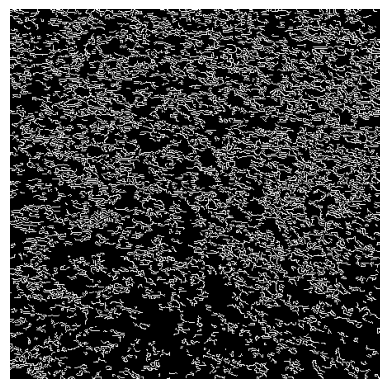

In [16]:
import matplotlib.pyplot as plt

plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
edge_count = np.sum(edges > 0)
print("Edge Count: ", edge_count)
edge_density = np.mean(edges > 0)
print("Edge Density: ", edge_density)

Edge Count:  40394
Edge Density:  0.2012615593112245


In [28]:
features = np.concatenate([
    vector,
    [
        mean_brightness,
        contrast,
        dark_ratio,
        bright_ratio,
        edge_count,
        edge_density
    ]
])

print(features.shape)

(106,)


In [19]:
def extract_features(image_path):
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )
    resized = cv2.resize(gray,(10, 10))
    normalized = resized.astype(np.float32) / 255.0

    # 100 pixel features
    pixel_features = normalized.flatten()

    # NumPy intensity features
    mean_brightness = np.mean(normalized)
    contrast = np.std(normalized)
    dark_ratio = np.mean(normalized < 0.3)
    bright_ratio = np.mean(normalized > 0.7)

    # Canny
    edges = cv2.Canny(
        gray,
        100,
        200
    )

    # Canny features
    edge_count = np.sum(edges > 0)
    edge_density = np.mean(edges > 0)

    # Final feature vector
    features = np.concatenate([
        pixel_features,
        [
            mean_brightness,
            contrast,
            dark_ratio,
            bright_ratio,
            edge_count,
            edge_density
        ]
    ])

    return features

In [29]:
features = extract_features(image_path)
print(features.shape)

(106,)


In [30]:
X = []
y = []
crack_folder = "448/Cracks"
for filename in os.listdir(crack_folder):

    image_path = os.path.join(
        crack_folder,
        filename
    )

    features = extract_features(image_path)

    X.append(features)
    y.append(1)

noncrack_folder = "448/NonCracks"
for filename in os.listdir(noncrack_folder):

    image_path = os.path.join(
        noncrack_folder,
        filename
    )

    features = extract_features(image_path)

    X.append(features)
    y.append(0)

In [31]:
X = np.array(X)
y = np.array(y)
print("X:", X.shape)
print("y:", y.shape)

print(np.unique(y, return_counts=True))

X: (400, 106)
y: (400,)
(array([0, 1]), array([200, 200]))


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(320, 106)
(80, 106)
(320,)
(80,)


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("Confusion Matrix: ")
print(confusion_matrix(y_test, y_pred))

Accuracy:  0.675
Precision:  0.6842105263157895
Recall:  0.65
F1 Score:  0.6666666666666666
Confusion Matrix: 
[[28 12]
 [14 26]]
